In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
files = {
    "add_to_cart": "add_to_cart.parquet",
    "product_buy": "product_buy.parquet",
    "remove_from_cart": "remove_from_cart.parquet",
    "search_query": "search_query.parquet",
    "product_properties": "product_properties.parquet"
}

In [3]:
for name, path in files.items():
    df = pd.read_parquet(path)

    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"{'='*50}")

    print("Shape:", df.shape)

    print("\nColumns and data types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

    print("\nFirst 5 rows:")
    display(df.head())


Dataset: add_to_cart
Shape: (7541117, 3)

Columns and data types:
client_id    int64
timestamp      str
sku          int64
dtype: object

Missing values:
client_id    0
timestamp    0
sku          0
dtype: int64

Duplicate rows:
161493

First 5 rows:


,client_id,timestamp,sku
0,18080713,2022-08-06 15:17:25,219064
1,8081030,2022-09-19 17:45:25,1375125
2,4480154,2022-12-06 06:35:15,1291128
3,3411058,2022-11-21 21:50:30,1523102
4,10551361,2022-09-22 06:26:40,728970



Dataset: product_buy
Shape: (2318502, 3)

Columns and data types:
client_id    int64
timestamp      str
sku          int64
dtype: object

Missing values:
client_id    0
timestamp    0
sku          0
dtype: int64

Duplicate rows:
380903

First 5 rows:


,client_id,timestamp,sku
0,14534769,2022-07-07 20:03:10,91300
1,14534769,2022-12-02 12:32:05,660194
2,4480154,2022-12-06 06:38:20,1291128
3,3411058,2022-11-21 21:47:35,1523102
4,10551361,2022-09-22 06:28:20,728970



Dataset: remove_from_cart
Shape: (2688894, 3)

Columns and data types:
client_id    int64
timestamp      str
sku          int64
dtype: object

Missing values:
client_id    0
timestamp    0
sku          0
dtype: int64

Duplicate rows:
153588

First 5 rows:


,client_id,timestamp,sku
0,4480154,2022-12-06 06:35:30,551275
1,10551361,2022-09-22 06:26:55,728970
2,10551361,2022-10-15 20:20:05,655683
3,10522335,2022-08-06 09:23:15,606762
4,10522335,2022-08-06 09:23:20,606762



Dataset: search_query
Shape: (13223769, 3)

Columns and data types:
client_id    int64
timestamp      str
query          str
dtype: object

Missing values:
client_id    0
timestamp    0
query        0
dtype: int64

Duplicate rows:
617143

First 5 rows:


,client_id,timestamp,query
0,14554694,2022-10-15 20:06:40,[240 170 240 207 251 138 16 169 162 254 170 1...
1,14554694,2022-10-15 20:07:00,[174 61 58 154 154 57 102 102 195 167 68 ...
2,2406455,2022-07-12 06:15:30,[250 172 48 48 7 122 145 116 60 122 204 2...
3,11556051,2022-06-29 08:05:55,[251 0 96 230 142 99 70 204 113 150 228 ...
4,11556051,2022-06-29 08:06:00,[ 60 185 170 134 246 75 8 232 113 113 228 1...



Dataset: product_properties
Shape: (1534050, 4)

Columns and data types:
sku         int64
category    int64
price       int64
name          str
dtype: object

Missing values:
sku         0
category    0
price       0
name        0
dtype: int64

Duplicate rows:
0

First 5 rows:


,sku,category,price,name
0,1263699,780,26,[193 102 221 13 57 176 57 99 169 14 242 ...
1,742320,4220,64,[ 95 172 124 189 137 196 226 95 237 124 1 1...
2,1201131,2243,37,[187 187 187 187 187 187 187 187 187 187 187 1...
3,167164,3130,38,[125 189 171 189 186 207 42 31 113 219 221 1...
4,1350853,3863,85,[175 21 3 157 93 71 123 76 57 95 235 ...


In [4]:
add_to_cart = pd.read_parquet("add_to_cart.parquet")
product_buy = pd.read_parquet("product_buy.parquet")
remove_from_cart = pd.read_parquet("remove_from_cart.parquet")

core_datasets = {
    "add_to_cart": add_to_cart,
    "product_buy": product_buy,
    "remove_from_cart": remove_from_cart
}

for name, df in core_datasets.items():
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    print(f"\n{name}")
    print("Invalid timestamps:", df["timestamp"].isna().sum())
    print("Earliest timestamp:", df["timestamp"].min())
    print("Latest timestamp:", df["timestamp"].max())


add_to_cart
Invalid timestamps: 0
Earliest timestamp: 2022-06-23 00:10:20
Latest timestamp: 2022-12-08 00:09:55

product_buy
Invalid timestamps: 0
Earliest timestamp: 2022-06-23 00:12:15
Latest timestamp: 2022-12-08 00:09:15

remove_from_cart
Invalid timestamps: 0
Earliest timestamp: 2022-06-23 00:12:25
Latest timestamp: 2022-12-08 00:09:40


In [5]:
for name, df in core_datasets.items():
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(
        ["client_id", "timestamp", "sku"]
    )

    print(f"\n{name}")
    print("Duplicate rows:", df.duplicated().sum())
    display(duplicate_rows.head(20))


add_to_cart
Duplicate rows: 161493


,client_id,timestamp,sku
5392489,510,2022-11-19 11:54:10,957345
5392490,510,2022-11-19 11:54:10,957345
6782681,603,2022-11-13 22:53:05,1299657
6782682,603,2022-11-13 22:53:05,1299657
769723,663,2022-10-09 17:17:40,1289093
769724,663,2022-10-09 17:17:40,1289093
3873709,1238,2022-11-06 14:19:05,4177
3873710,1238,2022-11-06 14:19:05,4177
1184451,1743,2022-12-02 13:50:20,1305737
1184452,1743,2022-12-02 13:50:20,1305737



product_buy
Duplicate rows: 380903


,client_id,timestamp,sku
1428951,84,2022-08-22 11:41:35,402699
1428952,84,2022-08-22 11:41:35,402699
200439,332,2022-11-28 13:18:05,821646
200440,332,2022-11-28 13:18:05,821646
776507,387,2022-11-27 19:41:45,364790
776511,387,2022-11-27 19:41:45,364790
776504,387,2022-11-27 19:41:45,379641
776508,387,2022-11-27 19:41:45,379641
776506,387,2022-11-27 19:41:45,706401
776510,387,2022-11-27 19:41:45,706401



remove_from_cart
Duplicate rows: 153588


,client_id,timestamp,sku
1651065,84,2022-09-15 14:53:20,789585
1651066,84,2022-09-15 14:53:20,789585
246021,422,2022-10-15 19:15:40,731458
246022,422,2022-10-15 19:15:40,731458
1929337,510,2022-07-28 01:36:25,236813
1929338,510,2022-07-28 01:36:25,236813
1929341,510,2022-11-19 11:54:20,957345
1929342,510,2022-11-19 11:54:20,957345
2420038,603,2022-11-13 22:53:30,1299657
2420039,603,2022-11-13 22:53:30,1299657


In [6]:
add_to_cart_clean = add_to_cart.drop_duplicates().copy()
product_buy_clean = product_buy.drop_duplicates().copy()
remove_from_cart_clean = remove_from_cart.drop_duplicates().copy()

clean_datasets = {
    "add_to_cart": add_to_cart_clean,
    "product_buy": product_buy_clean,
    "remove_from_cart": remove_from_cart_clean
}

for name, df in clean_datasets.items():
    print(f"{name}: {len(df):,} rows")

add_to_cart: 7,379,624 rows
product_buy: 1,937,599 rows
remove_from_cart: 2,535,306 rows


In [7]:
duplicate_summary = []

for name, raw_df in core_datasets.items():
    clean_df = clean_datasets[name]

    duplicate_summary.append({
        "Event Type": name,
        "Original Rows": len(raw_df),
        "Exact Duplicates": len(raw_df) - len(clean_df),
        "Duplicate Rate (%)": round(
            (len(raw_df) - len(clean_df)) / len(raw_df) * 100, 2
        ),
        "Rows After Cleaning": len(clean_df)
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)
duplicate_summary_df

,Event Type,Original Rows,Exact Duplicates,Duplicate Rate (%),Rows After Cleaning
0,add_to_cart,7541117,161493,2.14,7379624
1,product_buy,2318502,380903,16.43,1937599
2,remove_from_cart,2688894,153588,5.71,2535306


In [8]:
summary = []

for name, df in clean_datasets.items():
    summary.append({
        "Event Type": name,
        "Number of Events": len(df),
        "Unique Users": df["client_id"].nunique(),
        "Unique Products": df["sku"].nunique()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Event Type,Number of Events,Unique Users,Unique Products
0,add_to_cart,7379624,2333463,1444160
1,product_buy,1937599,909210,639126
2,remove_from_cart,2535306,694391,824536


## Purchase-History Sparsity

In [9]:
purchases_per_user = (
    product_buy_clean
    .groupby("client_id")
    .size()
)

print("Number of purchasing users:", len(purchases_per_user))
print("Mean purchases per user:", purchases_per_user.mean())
print("Median purchases per user:", purchases_per_user.median())
print("Minimum purchases per user:", purchases_per_user.min())
print("Maximum purchases per user:", purchases_per_user.max())

print(
    "Users with exactly 1 purchase:",
    (purchases_per_user == 1).sum()
)

print(
    "Users with <= 5 purchases:",
    (purchases_per_user <= 5).sum()
)

print(
    "Percentage with exactly 1 purchase:",
    round((purchases_per_user == 1).mean() * 100, 2),
    "%"
)

print(
    "Percentage with <= 5 purchases:",
    round((purchases_per_user <= 5).mean() * 100, 2),
    "%"
)

Number of purchasing users: 909210
Mean purchases per user: 2.131079728555559
Median purchases per user: 1.0
Minimum purchases per user: 1
Maximum purchases per user: 644
Users with exactly 1 purchase: 576862
Users with <= 5 purchases: 856213
Percentage with exactly 1 purchase: 63.45 %
Percentage with <= 5 purchases: 94.17 %


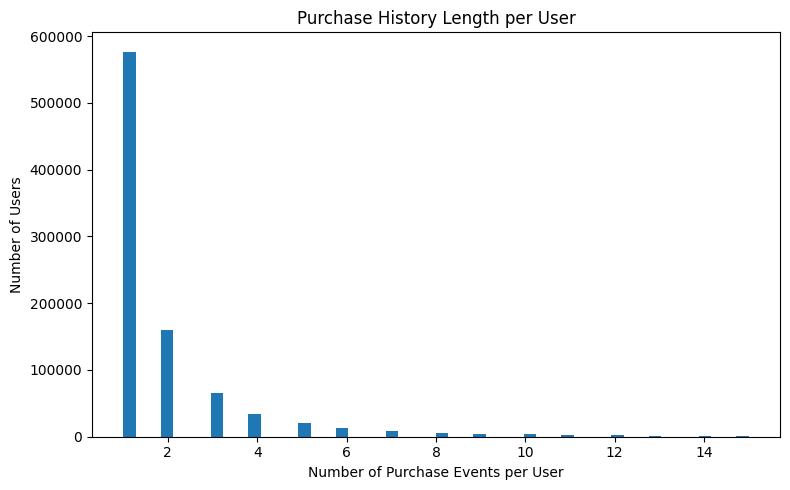

In [10]:
plt.figure(figsize=(8, 5))

upper_bound = purchases_per_user.quantile(0.99)

plt.hist(
    purchases_per_user[purchases_per_user <= upper_bound],
    bins=50
)

plt.xlabel("Number of Purchase Events per User")
plt.ylabel("Number of Users")
plt.title("Purchase History Length per User")

plt.tight_layout()
plt.show()

In [11]:
purchase_users = set(product_buy_clean["client_id"].unique())
cart_users = set(add_to_cart_clean["client_id"].unique())

users_with_both = purchase_users & cart_users

print("Purchasing users:", len(purchase_users))
print("Cart users:", len(cart_users))
print("Users with both:", len(users_with_both))

print(
    "Percentage of purchasing users with cart history:",
    round(len(users_with_both) / len(purchase_users) * 100, 2),
    "%"
)

Purchasing users: 909210
Cart users: 2333463
Users with both: 581678
Percentage of purchasing users with cart history: 63.98 %


In [12]:
only_purchase = purchase_users - cart_users
only_cart = cart_users - purchase_users

print("Purchase only:", len(only_purchase))
print("Cart only:", len(only_cart))
print("Both:", len(users_with_both))

Purchase only: 327532
Cart only: 1751785
Both: 581678


In [13]:
first_cart = (
    add_to_cart_clean
    .groupby(["client_id", "sku"], as_index=False)["timestamp"]
    .min()
    .rename(columns={"timestamp": "first_cart_time"})
)

first_purchase = (
    product_buy_clean
    .groupby(["client_id", "sku"], as_index=False)["timestamp"]
    .min()
    .rename(columns={"timestamp": "first_purchase_time"})
)

print("Unique user-item pairs with cart activity:", len(first_cart))
print("Unique user-item pairs with purchases:", len(first_purchase))

Unique user-item pairs with cart activity: 5791963
Unique user-item pairs with purchases: 1817928


In [14]:
cart_purchase = first_cart.merge(
    first_purchase,
    on=["client_id", "sku"],
    how="left"
)

cart_purchase["subsequently_purchased"] = (
    cart_purchase["first_purchase_time"].notna()
    & (cart_purchase["first_purchase_time"] > cart_purchase["first_cart_time"])
)

print(
    "Carted user-item pairs:",
    len(cart_purchase)
)

print(
    "Subsequently purchased:",
    cart_purchase["subsequently_purchased"].sum()
)

print(
    "Subsequent purchase rate:",
    round(cart_purchase["subsequently_purchased"].mean() * 100, 2),
    "%"
)

Carted user-item pairs: 5791963
Subsequently purchased: 1173949
Subsequent purchase rate: 20.27 %


In [15]:
summary_table = pd.DataFrame({
    "Metric": [
        "Add-to-cart events",
        "Purchase events",
        "Purchasing users",
        "Purchasing users with exactly 1 purchase",
        "Purchasing users with ≤ 5 purchases",
        "Purchasing users with cart history"
    ],
    "Result": [
        f"{len(add_to_cart_clean):,}",
        f"{len(product_buy_clean):,}",
        f"{len(purchases_per_user):,}",
        f"{(purchases_per_user == 1).mean() * 100:.2f}%",
        f"{(purchases_per_user <= 5).mean() * 100:.2f}%",
        f"{len(users_with_both) / len(purchase_users) * 100:.2f}%"
    ]
})

summary_table

,Metric,Result
0,Add-to-cart events,"7,379,624"
1,Purchase events,"1,937,599"
2,Purchasing users,"909,210"
3,Purchasing users with exactly 1 purchase,63.45%
4,Purchasing users with ≤ 5 purchases,94.17%
5,Purchasing users with cart history,63.98%


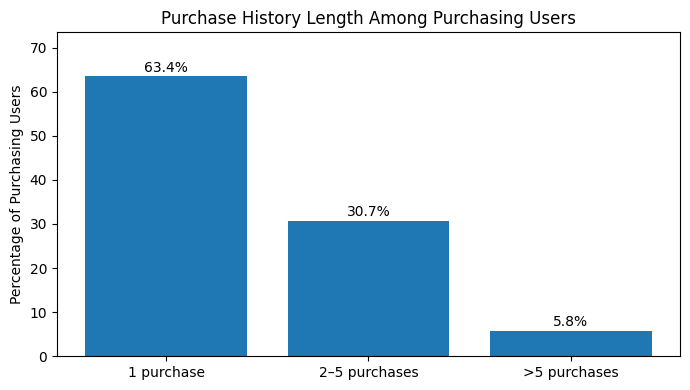

In [18]:
exactly_1 = (purchases_per_user == 1).mean() * 100
up_to_5 = (purchases_per_user <= 5).mean() * 100

two_to_five = up_to_5 - exactly_1
more_than_5 = 100 - up_to_5

labels = ["1 purchase", "2–5 purchases", ">5 purchases"]
values = [exactly_1, two_to_five, more_than_5]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(labels, values)

ax.set_ylabel("Percentage of Purchasing Users")
ax.set_title("Purchase History Length Among Purchasing Users")
ax.set_ylim(0, max(values) + 10)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

fig.tight_layout()

# Save BEFORE showing the figure
fig.savefig(
    "purchase_history_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

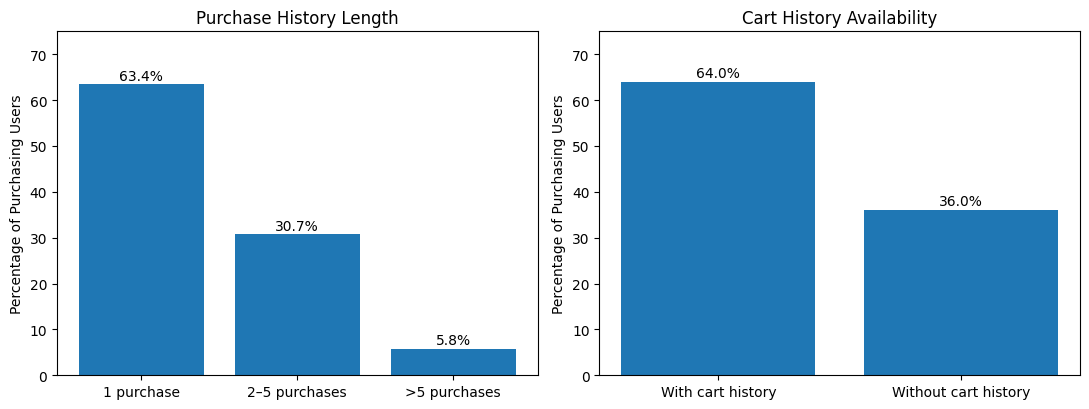

In [20]:
exactly_1 = (purchases_per_user == 1).mean() * 100
up_to_5 = (purchases_per_user <= 5).mean() * 100
two_to_five = up_to_5 - exactly_1
more_than_5 = 100 - up_to_5

with_cart = len(users_with_both) / len(purchase_users) * 100
without_cart = 100 - with_cart

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left panel: purchase history length
labels_left = ["1 purchase", "2–5 purchases", ">5 purchases"]
values_left = [exactly_1, two_to_five, more_than_5]

bars_left = axes[0].bar(labels_left, values_left)

axes[0].set_ylabel("Percentage of Purchasing Users")
axes[0].set_title("Purchase History Length")
axes[0].set_ylim(0, 75)

for bar, value in zip(bars_left, values_left):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

# Right panel: cart history availability
labels_right = ["With cart history", "Without cart history"]
values_right = [with_cart, without_cart]

bars_right = axes[1].bar(labels_right, values_right)

axes[1].set_ylabel("Percentage of Purchasing Users")
axes[1].set_title("Cart History Availability")
axes[1].set_ylim(0, 75)

for bar, value in zip(bars_right, values_right):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

fig.tight_layout()

fig.savefig(
    "preliminary_results_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()